<a href="https://colab.research.google.com/github/Ontiomacer/HBSS-Main/blob/main/iot_ai_ml_threat_detection_FIXED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI/ML-Based IoT Threat Detection using Anomaly Detection and Predictive Analysis


This notebook implements:

- IoT anomaly detection using Isolation Forest
- Threat classification using Random Forest
- Visualization and evaluation
- Multi-file dataset upload support
- Safe preprocessing for large IoT datasets


In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries Imported Successfully")


Libraries Imported Successfully


## Upload One or More CSV Dataset Files

In [1]:
from google.colab import files

uploaded = files.upload()


Saving data_74.csv to data_74.csv


In [5]:
import pandas as pd
import numpy as np

In [6]:
all_dfs = []

for file_name in uploaded.keys():
    print(f"Loading: {file_name}")

    try:
        temp_df = pd.read_csv(file_name)
    except:
        try:
            temp_df = pd.read_csv(file_name, sep=';')
        except:
            temp_df = pd.read_csv(file_name, sep='\t')

    all_dfs.append(temp_df)

df = pd.concat(all_dfs, ignore_index=True)

print("Dataset Loaded Successfully")
print("Dataset Shape:", df.shape)

df.head()


Loading: data_74.csv


/tmp/ipykernel_18063/1406968965.py:7: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file_name)


Dataset Loaded Successfully
Dataset Shape: (370443, 35)


,pkSeqID,stime,flgs,proto,saddr,sport,daddr,dport,pkts,bytes,...,spkts,dpkts,sbytes,dbytes,rate,srate,drate,attack,category,subcategory
0,73000001,1.528102e+09,e,udp,192.168.100.147,26077,192.168.100.7,80,4,240,...,4,0,240,0,0.363599,0.363599,0.0,1,DDoS,UDP
1,73000002,1.528102e+09,e,udp,192.168.100.147,26078,192.168.100.7,80,4,240,...,4,0,240,0,0.363599,0.363599,0.0,1,DDoS,UDP
2,73000003,1.528102e+09,e,udp,192.168.100.147,26079,192.168.100.7,80,4,240,...,4,0,240,0,0.363599,0.363599,0.0,1,DDoS,UDP
3,73000004,1.528102e+09,e,udp,192.168.100.147,26080,192.168.100.7,80,4,240,...,4,0,240,0,0.363599,0.363599,0.0,1,DDoS,UDP
4,73000005,1.528102e+09,e,udp,192.168.100.147,26081,192.168.100.7,80,4,240,...,4,0,240,0,0.363599,0.363599,0.0,1,DDoS,UDP


## Optional: Reduce Dataset Size for Faster Training

In [7]:
if len(df) > 50000:
    df = df.sample(n=50000, random_state=42)

print("Reduced Dataset Shape:", df.shape)


Reduced Dataset Shape: (50000, 35)


## Safe Missing Value Handling

In [8]:
# DO NOT use dropna() for IoT datasets

df = df.fillna(0)

print("Missing Values Handled Successfully")
print(df.shape)


Missing Values Handled Successfully
(50000, 35)


In [10]:
from sklearn.preprocessing import LabelEncoder

## Encode Categorical Features

In [11]:
label_encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label_encoder.fit_transform(df[column].astype(str))

print("Encoding Complete")


Encoding Complete


## Display Dataset Columns

In [12]:
print(df.columns)


Index(['pkSeqID', 'stime', 'flgs', 'proto', 'saddr', 'sport', 'daddr', 'dport',
       'pkts', 'bytes', 'state', 'ltime', 'seq', 'dur', 'mean', 'stddev',
       'smac', 'dmac', 'sum', 'min', 'max', 'soui', 'doui', 'sco', 'dco',
       'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'srate', 'drate',
       'attack', 'category', 'subcategory '],
      dtype='object')



## Set Target Column

Choose the correct target column based on your dataset.

Common options:
- attack
- category
- label
- subcategory


In [13]:
target_column = 'attack'


## Create Features and Labels

In [14]:
X = df.drop(target_column, axis=1)
y = df[target_column]

print("Feature Shape:", X.shape)
print("Label Shape:", y.shape)


Feature Shape: (50000, 34)
Label Shape: (50000,)


In [16]:
from sklearn.preprocessing import StandardScaler

## Normalize Features

In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Normalization Complete")
print(X_scaled.shape)


Normalization Complete
(50000, 34)


In [19]:
from sklearn.model_selection import train_test_split

## Train/Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (40000, 34)
Testing Shape: (10000, 34)


In [22]:
from sklearn.ensemble import IsolationForest

## Anomaly Detection using Isolation Forest

In [23]:
isolation_model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

isolation_model.fit(X_train)

print("Isolation Forest Trained Successfully")


Isolation Forest Trained Successfully


In [24]:
anomaly_predictions = isolation_model.predict(X_test)

anomaly_predictions = np.where(anomaly_predictions == -1, 1, 0)

print("Sample Anomaly Predictions:")
print(anomaly_predictions[:20])


Sample Anomaly Predictions:
[0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0]


In [26]:
from sklearn.ensemble import RandomForestClassifier

## Threat Classification using Random Forest

In [27]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Trained Successfully")


Random Forest Trained Successfully


In [28]:
y_pred = rf_model.predict(X_test)


In [30]:
from sklearn.metrics import accuracy_score

## Accuracy

In [31]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 1.0


In [33]:
from sklearn.metrics import classification_report

## Classification Report

In [34]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       1.00      1.00      1.00     10000

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [38]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Confusion Matrix

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


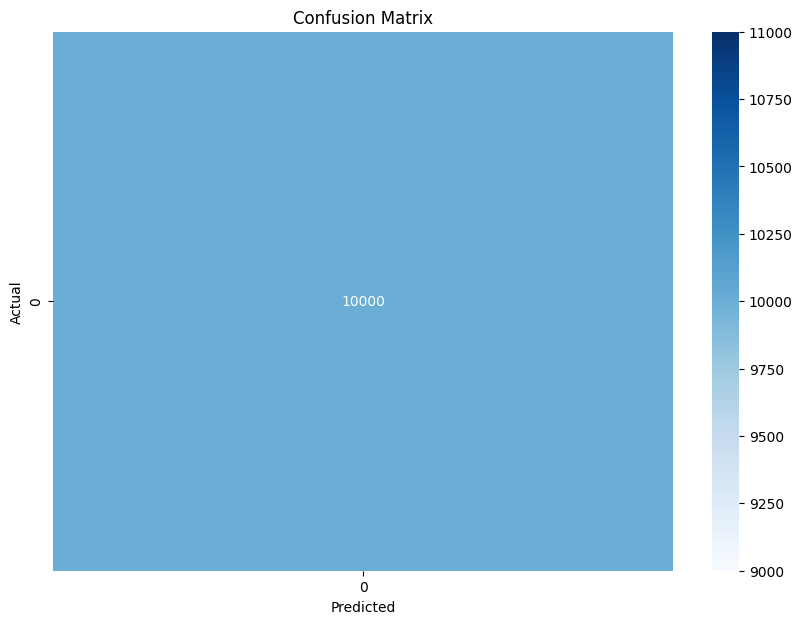

In [39]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


## Feature Importance

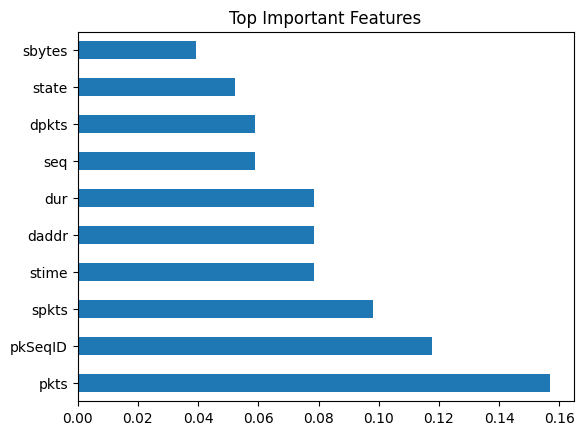

In [40]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

feature_importance.nlargest(10).plot(kind='barh')

plt.title('Top Important Features')

plt.show()


## Attack Distribution

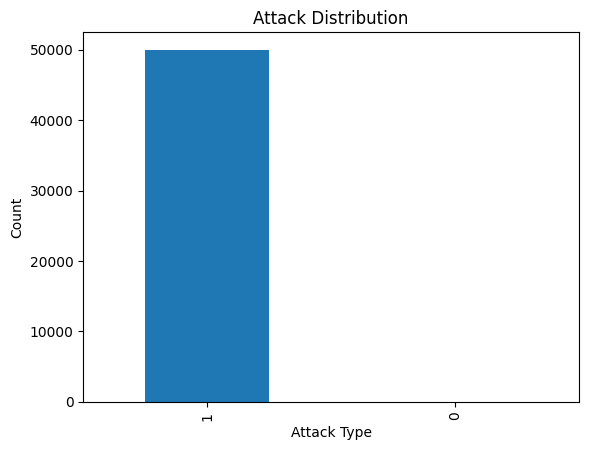

In [41]:
df[target_column].value_counts().plot(kind='bar')

plt.title("Attack Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Count")

plt.show()


## Anomaly Visualization

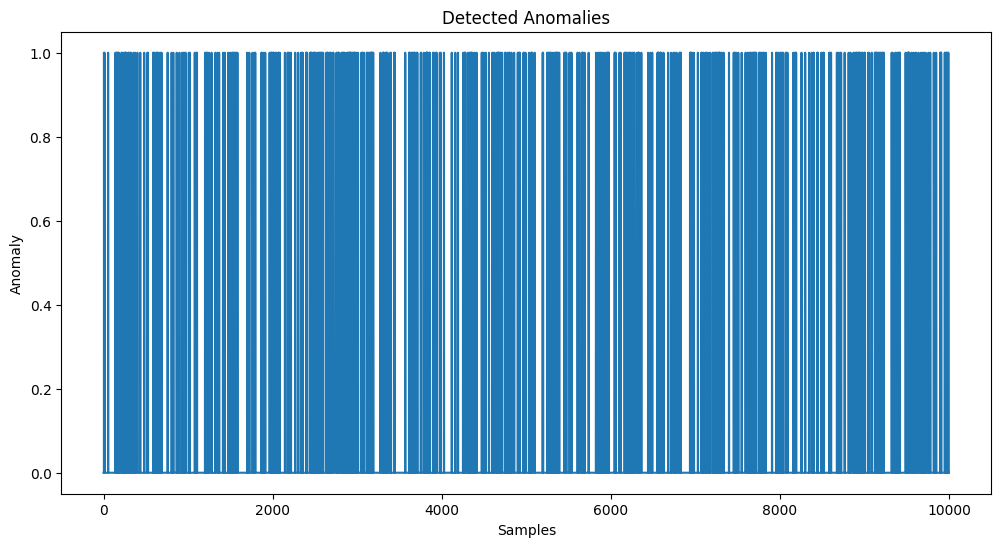

In [42]:
plt.figure(figsize=(12,6))

plt.plot(anomaly_predictions)

plt.title('Detected Anomalies')
plt.xlabel('Samples')
plt.ylabel('Anomaly')

plt.show()


## Real-Time Prediction Example

In [43]:
sample_data = X_test[0].reshape(1, -1)

prediction = rf_model.predict(sample_data)

print("Predicted Threat Type:", prediction)


Predicted Threat Type: [1]



# Conclusion

This notebook demonstrates:
- IoT anomaly detection
- Predictive threat analysis
- ML-based intrusion detection
- Cybersecurity analytics using AI/ML
